# 10 — F1 backtest (walk-forward)

Rewind the clock. For each historical week, pretend we were running F1 that week using only data available up to that week, then look at what actually happened in the next `lead_time_wk` weeks. This is the evidence that F1 would have caught real stockouts — i.e. the demo "money slide."

**Upstream:**
- `clean_demand_weekly.parquet` — used as input to `build_reorder_alerts` each iteration, truncated to `week_start < as_of_week`.
- `inv_weekly.parquet` — supplies both the simulated "today's inventory" at each as-of week AND the forward ground-truth window.
- `item_master.parquet` — lead time / case pack (same as step 09).
- `sales_tagged.parquet` *(optional)* — `is_stockout_week` / `is_lost_demand_week` as a second ground-truth signal.

**Walk-forward loop:**

```
for as_of_week in range(start, end, step):
    weekly_truncated = weekly[week_start < as_of_week]
    inv_at_as_of     = inv_weekly[week_start == as_of_week]  # synthesize snapshot shape
    alerts           = build_reorder_alerts(weekly_truncated, inv_at_as_of, im)
    alerts['as_of_week'] = as_of_week
    store(alerts)
```

**Ground-truth forward check** (per alert row):
- `forward_stockout` — any week in `(as_of_week, as_of_week + lead_time_wk]` has `on_hand_est ≤ 0`.
- `weeks_until_stockout` — weeks from `as_of_week` to first `on_hand_est ≤ 0` event; `NaN` if none.
- `min_forward_cover` — worst `weeks_of_cover` in the lookahead window (using the same local run_rate).

**Confusion matrix** (per alert row): `reorder_flag` × `forward_stockout`.

**Scope:** all SKUs × DCs with `confidence='high'` at their as-of week. Showcase deep-dive on `T-32206 SF` (the known-dip lane).

**Test window:** `as_of_week ∈ [2023-04-03, 2025-10-13]` (skips first 13 weeks to let clean-demand accumulate; ends ≥ 26 wk before anchor so lookahead has data).

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
ART = ROOT / 'pipeline' / 'artifacts'
FIG = ART / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.reorder import (
    DEFAULT_LEAD_WEEKS,
    build_reorder_alerts,
    prepare_item_master,
)

## 2. Load upstream

In [2]:
weekly     = pd.read_parquet(ART / 'clean_demand_weekly.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')
im         = pd.read_parquet(ART / 'item_master.parquet')
po         = pd.read_parquet(ART / 'po.parquet')

weekly['week_start']     = pd.to_datetime(weekly['week_start'])
inv_weekly['week_start'] = pd.to_datetime(inv_weekly['week_start'])
po['PO Date']            = pd.to_datetime(po['PO Date'])
po['Receipt Date']       = pd.to_datetime(po['Receipt Date'])

DC_MAP = {'1': 'SF', '2': 'NJ', '3': 'LA'}

print(f'clean_demand_weekly : {weekly.shape}  ({weekly["week_start"].min().date()} → {weekly["week_start"].max().date()})')
print(f'inv_weekly          : {inv_weekly.shape}  ({inv_weekly["week_start"].min().date()} → {inv_weekly["week_start"].max().date()})')
print(f'item_master         : {im.shape}')
print(f'po                  : {po.shape}')

clean_demand_weekly : (35591, 8)  (2023-01-02 → 2026-04-13)
inv_weekly          : (37887, 5)  (2023-01-02 → 2026-04-20)
item_master         : (65, 15)
po                  : (5281, 16)


## 3. Walk-forward harness

Two helpers:
- `alerts_as_of(as_of_week, ...)` — synthesize a snapshot-shape inv DataFrame at `as_of_week`, truncate weekly history, call `build_reorder_alerts`.
- `attach_forward_truth(alerts, inv_weekly)` — for each alert row, look forward `lead_time_wk` weeks and compute ground-truth columns.

In [3]:
def alerts_as_of(as_of_week: pd.Timestamp,
                 weekly: pd.DataFrame,
                 inv_weekly: pd.DataFrame,
                 im: pd.DataFrame,
                 po: pd.DataFrame,
                 dc_map: dict,
                 **kwargs) -> pd.DataFrame:
    """Produce the alert table *as if* today were as_of_week.

    - weekly truncated to week_start < as_of_week.
    - po truncated to Receipt Date < as_of_week (only POs received by
      that point inform the lead-time median — avoids leaking future PO
      cadence into the backtest).
    - inv synthesized from inv_weekly row at week_start == as_of_week.
      We don't have historical 'Allocated', so Available := on_hand_est.
      This is a simplification but symmetric across all as-of weeks — bias
      cancels when comparing alerts to ground-truth dips.

    kwargs forwarded to build_reorder_alerts (e.g. run_rate_quantile).
    """
    past = weekly[weekly['week_start'] < as_of_week]
    if past.empty:
        return pd.DataFrame()

    snap = inv_weekly[inv_weekly['week_start'] == as_of_week].copy()
    if snap.empty:
        return pd.DataFrame()
    snap = snap.rename(columns={
        'ITEMNMBR': 'Item Number',
        'on_hand_est': 'On Hand',
    })
    snap['Available']   = snap['On Hand']
    snap['Description'] = None
    snap = snap[['Item Number', 'DC', 'Available', 'On Hand', 'Description']]

    past_po = po[po['Receipt Date'] < as_of_week]
    alerts = build_reorder_alerts(past, snap, im, po=past_po, dc_map=dc_map, **kwargs)
    alerts.insert(0, 'as_of_week', as_of_week)
    return alerts

In [4]:
def attach_forward_truth(alerts: pd.DataFrame,
                         inv_weekly: pd.DataFrame) -> pd.DataFrame:
    """Per alert row, look forward `lead_time_wk` weeks in inv_weekly and
    compute ground-truth columns:

      inv_at_asof           : on_hand_est at the as_of_week itself.
      forward_stockout      : any week in (as_of, as_of + lead] has on_hand_est <= 0.
      min_forward_on_hand   : the minimum on_hand_est in that window.
      weeks_until_stockout  : weeks from as_of_week to first stockout (NaN if none).
      fresh_stockout        : inv_at_asof > 0 AND forward_stockout.
                              This is the real early-warning event: F1 was asked to
                              predict a dip while inventory still looked healthy.
                              Persistent stockouts (inv already <=0) get excluded —
                              F1 isn't being "tested" there, just re-confirming a
                              stockout already in progress.
    """
    inv_idx = inv_weekly.set_index(['ITEMNMBR', 'DC']).sort_index()
    inv_point = inv_weekly.set_index(['ITEMNMBR', 'DC', 'week_start'])['on_hand_est']

    out = alerts.copy()
    inv_asof, fs, mfo, wus = [], [], [], []
    for _, r in out.iterrows():
        key = (r['ITEMNMBR'], r['DC'])
        lead = r['lead_time_wk'] if pd.notna(r['lead_time_wk']) else DEFAULT_LEAD_WEEKS
        window_end = r['as_of_week'] + pd.Timedelta(weeks=int(np.ceil(lead)))

        # inventory at the as-of moment itself
        inv_asof.append(inv_point.get((r['ITEMNMBR'], r['DC'], r['as_of_week']), np.nan))

        try:
            sub = inv_idx.loc[[key]]
        except KeyError:
            fs.append(False); mfo.append(np.nan); wus.append(np.nan); continue
        sub = sub[(sub['week_start'] > r['as_of_week']) & (sub['week_start'] <= window_end)]
        if sub.empty:
            fs.append(False); mfo.append(np.nan); wus.append(np.nan); continue
        dips = sub[sub['on_hand_est'] <= 0]
        fs.append(not dips.empty)
        mfo.append(sub['on_hand_est'].min())
        if not dips.empty:
            first_dip = dips['week_start'].min()
            wus.append((first_dip - r['as_of_week']).days / 7.0)
        else:
            wus.append(np.nan)

    out['inv_at_asof']          = inv_asof
    out['forward_stockout']     = fs
    out['min_forward_on_hand']  = mfo
    out['weeks_until_stockout'] = wus
    out['fresh_stockout']       = (out['inv_at_asof'] > 0) & out['forward_stockout']
    return out

## 4. Run the backtest

In [5]:
START = pd.Timestamp('2023-04-03')   # 13 wk after inv_weekly start — give run_rate time to stabilize
END   = pd.Timestamp('2025-10-13')   # ≥ 26 wk before anchor so lookahead window has data
STEP  = pd.Timedelta(weeks=4)        # 4-week cadence keeps runs reasonable; tighten to 1 wk if needed

as_of_weeks = pd.date_range(START, END, freq=STEP)
print(f'as_of_weeks: {len(as_of_weeks)} iterations ({as_of_weeks[0].date()} → {as_of_weeks[-1].date()}, step={STEP.days}d)')

frames = []
for i, w in enumerate(as_of_weeks):
    a = alerts_as_of(w, weekly, inv_weekly, im, po, DC_MAP)
    if not a.empty:
        frames.append(a)
    if i % 10 == 0:
        print(f'  [{i+1}/{len(as_of_weeks)}] {w.date()}  rows={0 if a.empty else len(a)}')

alerts_wf = pd.concat(frames, ignore_index=True)
print(f'\nalerts_wf raw: {alerts_wf.shape}')
print(f'flagged: {int(alerts_wf["reorder_flag"].sum())} / {len(alerts_wf)}')
print(f'lead source: {alerts_wf["lead_time_source"].value_counts().to_dict()}')

as_of_weeks: 34 iterations (2023-04-03 → 2025-10-13, step=28d)
  [1/34] 2023-04-03  rows=161


  [11/34] 2024-01-08  rows=206


  [21/34] 2024-10-14  rows=214


  [31/34] 2025-07-21  rows=229

alerts_wf raw: (7084, 27)
flagged: 3095 / 7084
lead source: {'default': 3405, 'po_history': 2438, 'parsed': 1241}


In [6]:
alerts_wf = attach_forward_truth(alerts_wf, inv_weekly)

# Restrict to high-confidence rows for the primary evaluation — low-confidence
# alerts include SKUs missing from item_master, which we already flag as "manual review".
eval_df = alerts_wf[alerts_wf['confidence'] == 'high'].copy()
print(f'high-confidence rows for eval: {len(eval_df)} / {len(alerts_wf)}')
print(f'unique (SKU×DC) lanes evaluated: {eval_df[["ITEMNMBR","DC"]].drop_duplicates().shape[0]}')

high-confidence rows for eval: 3520 / 7084
unique (SKU×DC) lanes evaluated: 116


## 5. Validate — confusion matrix, lead time of warning, per-SKU summary

Two measurements:
- **Raw `forward_stockout`** = any inv week in the lookahead dips ≤ 0. Includes persistent stockouts (inventory already down at as_of_week).
- **`fresh_stockout`** = inv was > 0 at as_of_week AND dips later. This is the real early-warning event F1 is being asked to catch. Persistent stockouts should be excluded from scoring because F1 isn't predicting them — just re-confirming an ongoing problem.

In [7]:
# Raw confusion (includes persistent stockouts) — for context only.
print('=== RAW: reorder_flag × forward_stockout (high-conf) ===')
print(pd.crosstab(eval_df['reorder_flag'], eval_df['forward_stockout'],
                  rownames=['alert'], colnames=['forward_stockout'], margins=True).to_string())

n_fs_raw   = int(eval_df['forward_stockout'].sum())
persistent = int(((eval_df['inv_at_asof'] <= 0) & eval_df['forward_stockout']).sum())
fresh      = int(eval_df['fresh_stockout'].sum())
print(f'\nOf {n_fs_raw} forward_stockout rows: {persistent} persistent '
      f'(inv already <=0 at as_of), {fresh} fresh (inv was >0, then dipped)')

# Fresh-only confusion — the real early-warning test.
# Exclude as_of rows where inv was already <=0: F1 is not being "tested" there.
healthy = eval_df[eval_df['inv_at_asof'] > 0].copy()
print(f'\n=== FRESH: reorder_flag × fresh_stockout (healthy as_of only, n={len(healthy)}) ===')
print(pd.crosstab(healthy['reorder_flag'], healthy['fresh_stockout'],
                  rownames=['alert'], colnames=['fresh_stockout'], margins=True).to_string())

tp = int((healthy['reorder_flag'] &  healthy['fresh_stockout']).sum())
fp = int((healthy['reorder_flag'] & ~healthy['fresh_stockout']).sum())
fn = int((~healthy['reorder_flag'] &  healthy['fresh_stockout']).sum())
tn = int((~healthy['reorder_flag'] & ~healthy['fresh_stockout']).sum())
precision = tp / (tp + fp) if (tp + fp) else float('nan')
recall    = tp / (tp + fn) if (tp + fn) else float('nan')
print(f'\nprecision = {tp}/{tp+fp} = {precision:.3f}')
print(f'recall    = {tp}/{tp+fn} = {recall:.3f}')

=== RAW: reorder_flag × forward_stockout (high-conf) ===
forward_stockout  False  True   All
alert                              
False              3288     8  3296
True                209    15   224
All                3497    23  3520

Of 23 forward_stockout rows: 11 persistent (inv already <=0 at as_of), 12 fresh (inv was >0, then dipped)

=== FRESH: reorder_flag × fresh_stockout (healthy as_of only, n=3509) ===
fresh_stockout  False  True   All
alert                            
False            3288     8  3296
True              209     4   213
All              3497    12  3509

precision = 4/213 = 0.019
recall    = 4/12 = 0.333


TP (fresh) rows: 4
count     4.000000
mean     10.000000
std       5.163978
min       4.000000
25%       7.000000
50%      10.000000
75%      13.000000
max      16.000000

saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/backtest_lead_of_warning.png


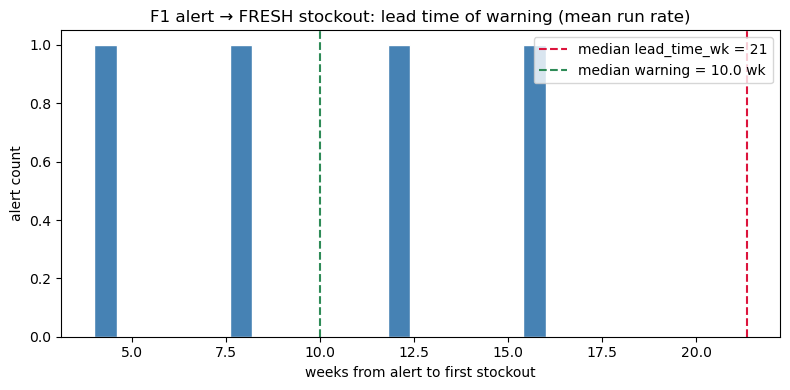

In [8]:
# Lead-of-warning on the fresh-stockout TPs: this is the demo metric.
tp_rows = healthy[healthy['reorder_flag'] & healthy['fresh_stockout']].copy()
print(f'TP (fresh) rows: {len(tp_rows)}')
if len(tp_rows):
    print(tp_rows['weeks_until_stockout'].describe().to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(tp_rows['weeks_until_stockout'].dropna(), bins=20, color='steelblue', edgecolor='white')
    ax.axvline(tp_rows['lead_time_wk'].median(), color='crimson', linestyle='--',
               label=f'median lead_time_wk = {tp_rows["lead_time_wk"].median():.0f}')
    ax.axvline(tp_rows['weeks_until_stockout'].median(), color='seagreen', linestyle='--',
               label=f'median warning = {tp_rows["weeks_until_stockout"].median():.1f} wk')
    ax.set_xlabel('weeks from alert to first stockout')
    ax.set_ylabel('alert count')
    ax.set_title('F1 alert → FRESH stockout: lead time of warning (mean run rate)')
    ax.legend()
    fig.tight_layout()
    out = FIG / 'backtest_lead_of_warning.png'
    fig.savefig(out, dpi=120)
    print(f'\nsaved: {out}')
    plt.show()

In [9]:
# Per-SKU×DC: how did the lane do across all its as-of weeks?
# Track both raw forward_stockout (all dips) and fresh_stockout (inv>0 at as_of).
per_lane = (
    eval_df.groupby(['ITEMNMBR', 'DC'])
           .agg(
               n_weeks=('as_of_week', 'nunique'),
               n_alerts=('reorder_flag', 'sum'),
               n_stockouts=('forward_stockout', 'sum'),
               n_fresh=('fresh_stockout', 'sum'),
               n_tp_raw=('reorder_flag', lambda s: int((s & eval_df.loc[s.index, 'forward_stockout']).sum())),
               n_fn_raw=('reorder_flag', lambda s: int((~s & eval_df.loc[s.index, 'forward_stockout']).sum())),
               n_tp_fresh=('reorder_flag', lambda s: int((s & eval_df.loc[s.index, 'fresh_stockout']).sum())),
               n_fn_fresh=('reorder_flag', lambda s: int((~s & eval_df.loc[s.index, 'fresh_stockout']).sum())),
           ).reset_index()
)
per_lane['alert_rate']       = per_lane['n_alerts']  / per_lane['n_weeks']
per_lane['stockout_rate']    = per_lane['n_stockouts'] / per_lane['n_weeks']
per_lane['fresh_rate']       = per_lane['n_fresh']  / per_lane['n_weeks']
print('=== per-lane summary (top 15 by fresh_rate) ===')
print(per_lane.sort_values('fresh_rate', ascending=False).head(15).to_string(index=False))

=== per-lane summary (top 15 by fresh_rate) ===
ITEMNMBR DC  n_weeks  n_alerts  n_stockouts  n_fresh  n_tp_raw  n_fn_raw  n_tp_fresh  n_fn_fresh  alert_rate  stockout_rate  fresh_rate
 T-32202 SF       34        15           16        6        10         6           0           6    0.441176       0.470588    0.176471
 D-15206 LA       27         0            2        2         0         2           0           2    0.000000       0.074074    0.074074
 A-61117 NJ       34         6            2        2         2         0           2           0    0.176471       0.058824    0.058824
 T-32206 SF       34         5            3        2         3         0           2           0    0.147059       0.088235    0.058824
 F-20141 NJ       34         0            0        0         0         0           0           0    0.000000       0.000000    0.000000
 F-20141 LA       34         0            0        0         0         0           0           0    0.000000       0.000000    0.000000


saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/backtest_t32206_sf_timeline.png


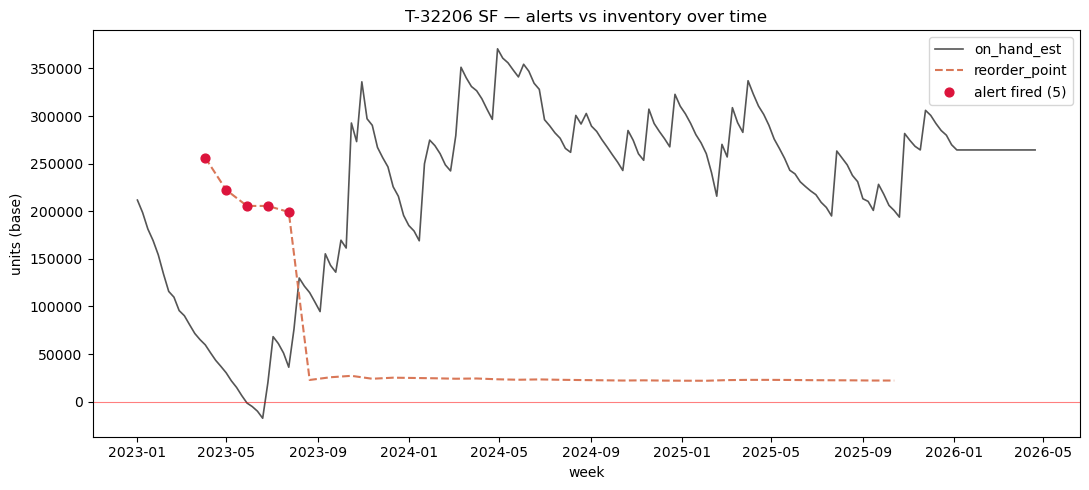

In [10]:
# Showcase: T-32206 SF timeline. Alerts vs on_hand_est vs reorder_point over time.
lane = alerts_wf[(alerts_wf['ITEMNMBR'] == 'T-32206') & (alerts_wf['DC'] == 'SF')].sort_values('as_of_week')
inv_sf = inv_weekly[(inv_weekly['ITEMNMBR'] == 'T-32206') & (inv_weekly['DC'] == 'SF')].sort_values('week_start')

if lane.empty or inv_sf.empty:
    print('T-32206 SF: no data in backtest window — skipping timeline plot.')
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(inv_sf['week_start'], inv_sf['on_hand_est'], color='#555', label='on_hand_est', linewidth=1.2)
    ax.plot(lane['as_of_week'], lane['reorder_point'], color='#d97757', label='reorder_point', linestyle='--')
    ax.axhline(0, color='red', linewidth=0.8, alpha=0.5)

    fires = lane[lane['reorder_flag']]
    if len(fires):
        ax.scatter(fires['as_of_week'], fires['reorder_point'],
                   color='crimson', s=40, zorder=5, label=f'alert fired ({len(fires)})')

    ax.set_xlabel('week')
    ax.set_ylabel('units (base)')
    ax.set_title('T-32206 SF — alerts vs inventory over time')
    ax.legend(loc='upper right')
    fig.tight_layout()
    out = FIG / 'backtest_t32206_sf_timeline.png'
    fig.savefig(out, dpi=120)
    print(f'saved: {out}')
    plt.show()

## 5b. Burst-aware p90 comparison

Re-run the backtest with `run_rate_quantile=0.9`. Hypothesis: p90 lifts median lead-of-warning (was 1 week with mean) by firing alerts sooner on lumpy lanes — without wrecking precision too badly. Same test window, same lanes, same confidence filter.

In [11]:
# Re-run walk-forward with run_rate_quantile=0.9. Inlined (doesn't use
# alerts_as_of) so the mean-variant artifacts above stay untouched.
frames_p90 = []
for i, w in enumerate(as_of_weeks):
    a = alerts_as_of(w, weekly, inv_weekly, im, po, DC_MAP, run_rate_quantile=0.9)
    if not a.empty:
        frames_p90.append(a)
    if i % 10 == 0:
        print(f'  [{i+1}/{len(as_of_weeks)}] {w.date()}  rows={0 if a.empty else len(a)}')

alerts_wf_p90 = pd.concat(frames_p90, ignore_index=True)
alerts_wf_p90 = attach_forward_truth(alerts_wf_p90, inv_weekly)
eval_p90 = alerts_wf_p90[alerts_wf_p90['confidence'] == 'high'].copy()
print(f'\np90 raw shape : {alerts_wf_p90.shape}')
print(f'p90 high-conf : {len(eval_p90)}  flagged={int(eval_p90.reorder_flag.sum())}')

  [1/34] 2023-04-03  rows=161


  [11/34] 2024-01-08  rows=206


  [21/34] 2024-10-14  rows=214


  [31/34] 2025-07-21  rows=229



p90 raw shape : (7084, 32)
p90 high-conf : 3520  flagged=351


In [12]:
# Score both variants. Primary metric is FRESH (inv>0 at as_of): F1 is only
# being "tested" on lanes where inventory still looked healthy. Persistent
# stockouts (inv already <=0) get excluded — F1 isn't forecasting those, just
# re-confirming a dip already in progress.
def score(df, label):
    healthy = df[df['inv_at_asof'] > 0]
    tp_f = int((healthy['reorder_flag'] &  healthy['fresh_stockout']).sum())
    fp_f = int((healthy['reorder_flag'] & ~healthy['fresh_stockout']).sum())
    fn_f = int((~healthy['reorder_flag'] &  healthy['fresh_stockout']).sum())
    tn_f = int((~healthy['reorder_flag'] & ~healthy['fresh_stockout']).sum())
    prec_f = tp_f / (tp_f + fp_f) if (tp_f + fp_f) else float('nan')
    rec_f  = tp_f / (tp_f + fn_f) if (tp_f + fn_f) else float('nan')
    tp_rows = healthy[healthy['reorder_flag'] & healthy['fresh_stockout']]
    med = float(tp_rows['weeks_until_stockout'].median()) if len(tp_rows) else float('nan')
    p25 = float(tp_rows['weeks_until_stockout'].quantile(0.25)) if len(tp_rows) else float('nan')
    p75 = float(tp_rows['weeks_until_stockout'].quantile(0.75)) if len(tp_rows) else float('nan')

    # Raw (includes persistent) — for context.
    tp_r = int((df['reorder_flag'] & df['forward_stockout']).sum())
    fp_r = int((df['reorder_flag'] & ~df['forward_stockout']).sum())
    fn_r = int((~df['reorder_flag'] & df['forward_stockout']).sum())
    prec_r = tp_r / (tp_r + fp_r) if (tp_r + fp_r) else float('nan')
    rec_r  = tp_r / (tp_r + fn_r) if (tp_r + fn_r) else float('nan')

    return {
        'method': label,
        'n_rows':    len(df),
        'n_healthy': len(healthy),
        'n_flagged': int(df['reorder_flag'].sum()),
        # fresh (primary)
        'tp_fresh': tp_f, 'fp_fresh': fp_f, 'fn_fresh': fn_f, 'tn_fresh': tn_f,
        'precision_fresh': round(prec_f, 3),
        'recall_fresh':    round(rec_f, 3),
        'med_warn_wk':     med,
        'p25_warn_wk':     p25,
        'p75_warn_wk':     p75,
        # raw (context)
        'precision_raw': round(prec_r, 3),
        'recall_raw':    round(rec_r, 3),
    }

cmp = pd.DataFrame([score(eval_df, 'mean'), score(eval_p90, 'p90')])
print('=== Mean vs p90 (primary: fresh) ===')
print(cmp.T.to_string())

=== Mean vs p90 (primary: fresh) ===
                     0      1
method            mean    p90
n_rows            3520   3520
n_healthy         3509   3509
n_flagged          224    351
tp_fresh             4      6
fp_fresh           209    334
fn_fresh             8      6
tn_fresh          3288   3163
precision_fresh  0.019  0.018
recall_fresh     0.333    0.5
med_warn_wk       10.0   10.0
p25_warn_wk        7.0    8.0
p75_warn_wk       13.0   12.0
precision_raw    0.067  0.048
recall_raw       0.652  0.739


saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/backtest_t32206_sf_mean_vs_p90.png


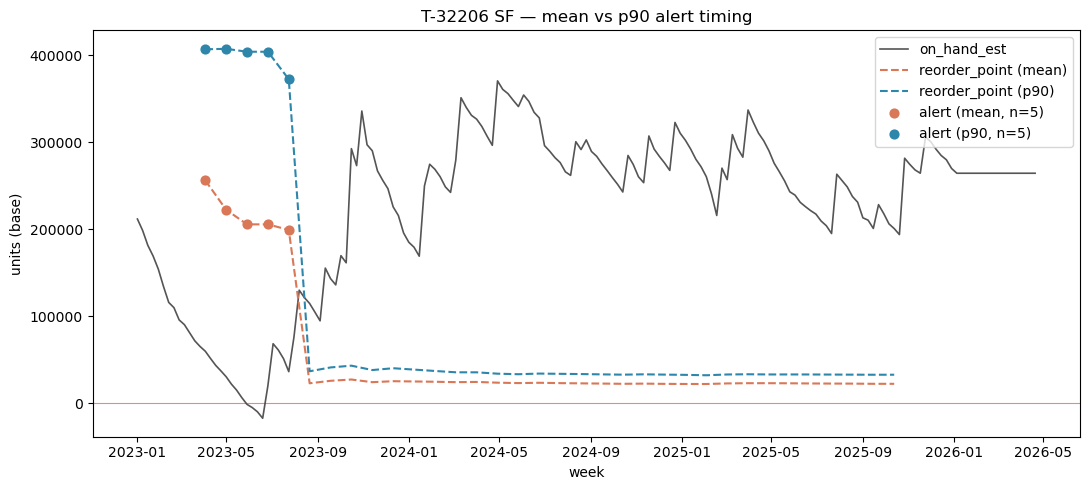

In [13]:
# T-32206 SF timeline under p90: show the reorder_point lifts, new alerts.
lane_p90 = alerts_wf_p90[(alerts_wf_p90['ITEMNMBR'] == 'T-32206') & (alerts_wf_p90['DC'] == 'SF')].sort_values('as_of_week')
inv_sf   = inv_weekly[(inv_weekly['ITEMNMBR'] == 'T-32206') & (inv_weekly['DC'] == 'SF')].sort_values('week_start')

if lane_p90.empty or inv_sf.empty:
    print('T-32206 SF (p90): no data — skipping.')
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(inv_sf['week_start'], inv_sf['on_hand_est'], color='#555', label='on_hand_est', linewidth=1.2)
    ax.plot(lane['as_of_week'],     lane['reorder_point'],     color='#d97757', linestyle='--', label='reorder_point (mean)')
    ax.plot(lane_p90['as_of_week'], lane_p90['reorder_point'], color='#2e86ab', linestyle='--', label='reorder_point (p90)')
    ax.axhline(0, color='red', linewidth=0.8, alpha=0.5)

    fires_mean = lane[lane['reorder_flag']]
    fires_p90  = lane_p90[lane_p90['reorder_flag']]
    if len(fires_mean):
        ax.scatter(fires_mean['as_of_week'], fires_mean['reorder_point'], color='#d97757', s=40, zorder=5, label=f'alert (mean, n={len(fires_mean)})')
    if len(fires_p90):
        ax.scatter(fires_p90['as_of_week'],  fires_p90['reorder_point'],  color='#2e86ab', s=40, zorder=5, label=f'alert (p90, n={len(fires_p90)})')

    ax.set_xlabel('week')
    ax.set_ylabel('units (base)')
    ax.set_title('T-32206 SF — mean vs p90 alert timing')
    ax.legend(loc='upper right')
    fig.tight_layout()
    out = FIG / 'backtest_t32206_sf_mean_vs_p90.png'
    fig.savefig(out, dpi=120)
    print(f'saved: {out}')
    plt.show()

## 5c. Counterfactual: "what if POP had followed our alerts?"

Replace POP's historical POs with POs triggered by our alert system. At each alert (reorder_flag=True), if no PO is in flight, place an order for `suggested_qty` arriving `lead_time_wk` weeks later. Actual outflow comes from the real sales history. We do NOT add POP's real POs on top — this shows whether our system alone can keep inventory healthy.

Lane: `T-32206 SF` (the dip-to-negative-17k lane). Expected: mean and p90 both prevent the 2023 dip; p90 keeps a higher floor.

In [14]:
# Build actual weekly outflow per (SKU, DC) from raw sales — signed (net of returns).
sales = pd.read_parquet(ART / 'sales.parquet')
sales['QTY_BASE'] = sales['QUANTITY_adj'].astype(float) * sales['QTYBSUOM'].fillna(1).astype(float)
sales['DC'] = sales['LOCNCODE'].astype(str).map({'1': 'SF', '2': 'NJ', '3': 'LA'})
sales = sales.dropna(subset=['DC'])
sales['week_start'] = pd.to_datetime(sales['DOCDATE']).dt.to_period('W-SUN').dt.start_time
outflow_wk = (sales.groupby(['ITEMNMBR', 'DC', 'week_start'], as_index=False)['QTY_BASE']
                   .sum()
                   .rename(columns={'QTY_BASE': 'outflow'}))
print(f'outflow_wk: {outflow_wk.shape}  ({outflow_wk.week_start.min().date()} → {outflow_wk.week_start.max().date()})')

from src.reorder import FORWARD_COVER_WEEKS, _round_up_case


def simulate_followed(lane_sku, lane_dc, alerts_wf_frame, outflow_wk, inv_weekly):
    """Roll on_hand forward using actual outflow + POs triggered by our alerts.

    Starts at the first as_of_week (seeded with that week's historical on_hand_est).

    Per-alert lead time: each alert row carries its own lead_time_wk (which
    may shift over the backtest as PO history accumulates). Using the
    row's own lead is more honest than pinning to the first one.

    (Q, r) inventory-position trigger:
      inventory_position = on_hand + sum(POs in transit)
      fire when inventory_position < reorder_point

    This lets a second PO stack on top of a first if one wasn't enough.
    reorder_point / run_rate / case_pack / lead_time are all borrowed from
    the alert row for that as_of_week.
    """
    alerts_lane = alerts_wf_frame[(alerts_wf_frame.ITEMNMBR == lane_sku) & (alerts_wf_frame.DC == lane_dc)].sort_values('as_of_week')
    if alerts_lane.empty:
        return pd.DataFrame()
    alerts_by_week = {r['as_of_week']: r for _, r in alerts_lane.iterrows()}
    start_week = alerts_lane['as_of_week'].min()

    inv_lane = inv_weekly[(inv_weekly.ITEMNMBR == lane_sku) & (inv_weekly.DC == lane_dc)].sort_values('week_start')
    seed = inv_lane[inv_lane['week_start'] == start_week]
    if seed.empty:
        return pd.DataFrame()
    on_hand = float(seed['on_hand_est'].iloc[0])

    outflow = (outflow_wk[(outflow_wk.ITEMNMBR == lane_sku) & (outflow_wk.DC == lane_dc)]
                         .set_index('week_start')['outflow'])

    weeks = inv_lane[inv_lane['week_start'] >= start_week]['week_start'].tolist()
    po_schedule = {}
    rows = []
    for w in weeks:
        po_arr_qty = po_schedule.pop(w, 0.0)
        on_hand += po_arr_qty
        out = float(outflow.get(w, 0.0))
        on_hand -= out
        alert_fires = False
        po_qty = 0.0
        if w in alerts_by_week:
            a = alerts_by_week[w]
            rp = float(a['reorder_point']) if pd.notna(a['reorder_point']) else float('nan')
            rr = float(a['run_rate_wk'])   if pd.notna(a['run_rate_wk'])   else 0.0
            cp = float(a['case_pack'])     if pd.notna(a['case_pack'])     else 1.0
            lead = float(a['lead_time_wk']) if pd.notna(a['lead_time_wk']) else 13.0
            inflight = sum(po_schedule.values())
            inv_position = on_hand + inflight
            if pd.notna(rp) and (inv_position < rp):
                raw = max(0.0, rp + FORWARD_COVER_WEEKS * rr - inv_position)
                po_qty = _round_up_case(raw, cp)
                if po_qty > 0:
                    arr = w + pd.Timedelta(weeks=int(round(lead)))
                    po_schedule[arr] = po_schedule.get(arr, 0.0) + po_qty
                    alert_fires = True
        rows.append({
            'week_start':  w,
            'on_hand_sim': on_hand,
            'outflow':     out,
            'po_arrives':  po_arr_qty,
            'alert_fires': alert_fires,
            'po_ordered':  po_qty,
            'inflight':    sum(po_schedule.values()),
        })
    return pd.DataFrame(rows)


sim_mean = simulate_followed('T-32206', 'SF', alerts_wf,     outflow_wk, inv_weekly)
sim_p90  = simulate_followed('T-32206', 'SF', alerts_wf_p90, outflow_wk, inv_weekly)
print(f'sim_mean: start={sim_mean["on_hand_sim"].iloc[0]:,.0f}  min={sim_mean["on_hand_sim"].min():,.0f}  final={sim_mean["on_hand_sim"].iloc[-1]:,.0f}  n_orders={int(sim_mean["alert_fires"].sum())}  total_ordered={sim_mean["po_ordered"].sum():,.0f}')
print(f'sim_p90 : start={sim_p90["on_hand_sim"].iloc[0]:,.0f}  min={sim_p90["on_hand_sim"].min():,.0f}  final={sim_p90["on_hand_sim"].iloc[-1]:,.0f}  n_orders={int(sim_p90["alert_fires"].sum())}  total_ordered={sim_p90["po_ordered"].sum():,.0f}')

outflow_wk: (22997, 4)  (2023-01-02 → 2026-04-13)
sim_mean: start=51,380  min=-159,630  final=-29,534  n_orders=27  total_ordered=1,198,872
sim_p90 : start=51,380  min=-159,630  final=-38,282  n_orders=16  total_ordered=1,190,124


saved: /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/figures/backtest_t32206_sf_counterfactual.png


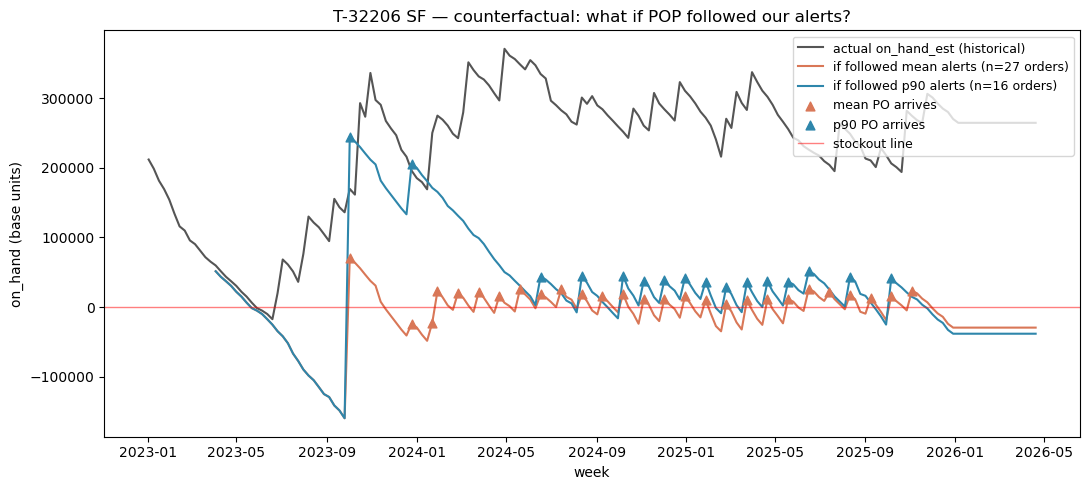

In [15]:
# Money-slide plot: actual vs mean-followed vs p90-followed.
lane_actual = inv_weekly[(inv_weekly.ITEMNMBR == 'T-32206') & (inv_weekly.DC == 'SF')].sort_values('week_start')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(lane_actual['week_start'], lane_actual['on_hand_est'],
        color='#555', linewidth=1.5, label='actual on_hand_est (historical)')
ax.plot(sim_mean['week_start'],    sim_mean['on_hand_sim'],
        color='#d97757', linewidth=1.5, label=f'if followed mean alerts (n={int(sim_mean.alert_fires.sum())} orders)')
ax.plot(sim_p90['week_start'],     sim_p90['on_hand_sim'],
        color='#2e86ab', linewidth=1.5, label=f'if followed p90 alerts (n={int(sim_p90.alert_fires.sum())} orders)')

# mark PO arrivals on the simulated lines
arr_mean = sim_mean[sim_mean['po_arrives'] > 0]
arr_p90  = sim_p90[sim_p90['po_arrives'] > 0]
ax.scatter(arr_mean['week_start'], arr_mean['on_hand_sim'], color='#d97757', s=40, marker='^', zorder=5, label='mean PO arrives')
ax.scatter(arr_p90['week_start'],  arr_p90['on_hand_sim'],  color='#2e86ab', s=40, marker='^', zorder=5, label='p90 PO arrives')

ax.axhline(0, color='red', linewidth=1.0, alpha=0.5, label='stockout line')
ax.set_xlabel('week')
ax.set_ylabel('on_hand (base units)')
ax.set_title('T-32206 SF — counterfactual: what if POP followed our alerts?')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
out = FIG / 'backtest_t32206_sf_counterfactual.png'
fig.savefig(out, dpi=120)
print(f'saved: {out}')
plt.show()

## 6. Save artifacts

In [16]:
alerts_wf.to_parquet(ART / 'backtest_alerts.parquet')
per_lane.to_parquet(ART / 'backtest_per_lane.parquet')
cmp.to_parquet(ART / 'backtest_compare.parquet')

# Primary summary is the fresh-stockout scoring of the mean variant.
healthy_m = eval_df[eval_df['inv_at_asof'] > 0]
tp_m = int((healthy_m['reorder_flag'] &  healthy_m['fresh_stockout']).sum())
fp_m = int((healthy_m['reorder_flag'] & ~healthy_m['fresh_stockout']).sum())
fn_m = int((~healthy_m['reorder_flag'] &  healthy_m['fresh_stockout']).sum())
tn_m = int((~healthy_m['reorder_flag'] & ~healthy_m['fresh_stockout']).sum())
prec_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) else float('nan')
rec_m  = tp_m / (tp_m + fn_m) if (tp_m + fn_m) else float('nan')
tp_rows_m = healthy_m[healthy_m['reorder_flag'] & healthy_m['fresh_stockout']]

summary_row = {
    'n_eval_rows':    len(eval_df),
    'n_healthy_rows': len(healthy_m),
    'n_lanes':        int(eval_df[['ITEMNMBR', 'DC']].drop_duplicates().shape[0]),
    'n_as_of':        int(eval_df['as_of_week'].nunique()),
    'tp_fresh': tp_m, 'fp_fresh': fp_m, 'fn_fresh': fn_m, 'tn_fresh': tn_m,
    'precision_fresh':      prec_m,
    'recall_fresh':         rec_m,
    'median_weeks_warning': float(tp_rows_m['weeks_until_stockout'].median()) if len(tp_rows_m) else float('nan'),
}
pd.DataFrame([summary_row]).to_parquet(ART / 'backtest_summary.parquet')
print(f'wrote:\n  {ART / "backtest_alerts.parquet"}  ({alerts_wf.shape})\n'
      f'  {ART / "backtest_per_lane.parquet"}  ({per_lane.shape})\n'
      f'  {ART / "backtest_compare.parquet"}   ({cmp.shape})\n'
      f'  {ART / "backtest_summary.parquet"}   (1 row)')

wrote:
  /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/backtest_alerts.parquet  ((7084, 32))
  /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/backtest_per_lane.parquet  ((116, 13))
  /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/backtest_compare.parquet   ((2, 15))
  /Users/johnpork/repos/pop_prompt2/pipeline/artifacts/backtest_summary.parquet   (1 row)


## 7. Promote

Once validation looks right, extract `alerts_as_of` + `attach_forward_truth` into `src/backtest.py` with a `run_backtest(weekly, inv_weekly, im, start, end, step) -> (alerts_wf, per_lane, summary)` entry point.